In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il
import pickle

In [23]:

plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [24]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [25]:
snapnum=40

In [26]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200", "Group_R_TopHat200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [27]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [28]:
mfof = np.log10(halos["GroupMass"]*1e10)

In [29]:
mvir_lin = halos["Group_M_TopHat200"]
mfof_lin = halos["GroupMass"]

In [30]:
rvir = halos["Group_R_TopHat200"]/1e3

In [31]:
sfrs = halos["GroupSFR"]

In [32]:
def lognormal(r, sigma, R):
    
    d = R*2
    fr = np.exp(-(np.log(r/d))**2/(2*sigma**2))/(r*sigma*np.sqrt(2*np.pi))
    return fr

In [ ]:
def lognormal_base10_same_params(r, sigma, R):
    
    d = R*2
    d = 10**(np.log(d)/np.log(10))
    fr = np.exp(-(np.log10(r/d))**2/(2*sigma**2))/(np.log(10)*r*sigma*np.sqrt(2*np.pi))
    return fr

In [ ]:
def lognormal_base10_same_params(r, sigma, R):
    
    d = R*2
    d = 10**(np.log(d)/np.log(10))
    fr = np.exp(-(np.log10(r/d))**2/(2*sigma**2))/(np.log(10)*r*sigma*np.sqrt(2*np.pi))
    return fr

In [33]:
import itertools

def sum_combinations(lst):
    sums = [x + y for x, y in itertools.combinations(lst, 2)]
    #sums.append(2*lst)
    return sums


In [46]:
mask10 = mvir > 11
mass_ratio = mfof_lin[mask10]/mvir_lin[mask10]
r_ratio = mass_ratio**(1/3)

In [ ]:
import time
start_time = time.time()
distances = sum_combinations(rvir[mask10]*mass_ratio)
end_time = time.time()
time_taken = end_time - start_time
print(time_taken)

35.16782760620117


In [38]:
tot_sfr = np.sum(sfrs[mask10])

In [39]:
distance_weights = sum_combinations(sfrs[mask10]/tot_sfr)

In [40]:
print(len(distances))

237870766


In [41]:
step = 1000

(array([2.00491528e+00, 2.70958656e+00, 1.49194212e+00, 7.13505645e-01,
        3.44554217e-01, 1.65803313e-01, 7.65073646e-02, 3.83972281e-02,
        2.01234461e-02, 1.06517228e-02, 4.43289858e-03, 2.64698500e-03,
        1.97726590e-03, 5.74043901e-04, 1.91348313e-04, 1.59456928e-04,
        3.18913855e-05, 0.00000000e+00, 0.00000000e+00, 3.18913855e-05]),
 array([0.43565348, 0.56747466, 0.6992959 , 0.8311171 , 0.9629383 ,
        1.0947596 , 1.2265807 , 1.358402  , 1.4902232 , 1.6220444 ,
        1.7538656 , 1.8856869 , 2.017508  , 2.1493292 , 2.2811506 ,
        2.4129717 , 2.544793  , 2.676614  , 2.8084354 , 2.9402566 ,
        3.0720778 ], dtype=float32),
 <BarContainer object of 20 artists>)

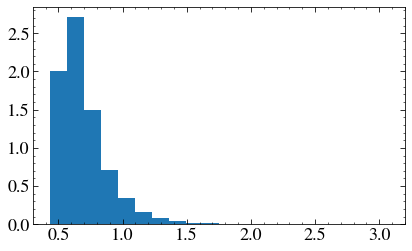

In [42]:

plt.hist(distances[::step], density=True, bins=20)


(array([1.34760886e+00, 2.20147923e+00, 1.53834208e+00, 9.84799414e-01,
        6.22284215e-01, 3.80357373e-01, 2.20042726e-01, 1.24015437e-01,
        6.87534174e-02, 4.46445362e-02, 1.92715108e-02, 1.37114273e-02,
        1.40579293e-02, 3.36341075e-03, 1.39972583e-03, 1.24035401e-03,
        2.00801929e-04, 0.00000000e+00, 0.00000000e+00, 4.60507712e-04]),
 array([0.43565348, 0.56747466, 0.6992959 , 0.8311171 , 0.9629383 ,
        1.0947596 , 1.2265807 , 1.358402  , 1.4902232 , 1.6220444 ,
        1.7538656 , 1.8856869 , 2.017508  , 2.1493292 , 2.2811506 ,
        2.4129717 , 2.544793  , 2.676614  , 2.8084354 , 2.9402566 ,
        3.0720778 ], dtype=float32),
 <BarContainer object of 20 artists>)

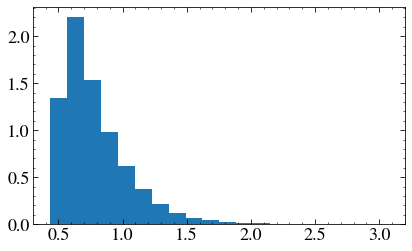

In [43]:
plt.hist(distances[::step], density=True, bins=20, weights=distance_weights[::step])